## Kernel Trick in Support Vector Machine (SVM)

The `Kernel Trick` is a powerful technique used in **Support Vector Machines**
to handle **non-linearly separable data**.  
It allows SVM to learn complex decision boundaries **without explicitly transforming**
data into higher-dimensional spaces.

---

### Why the Kernel Trick Is Needed

Linear SVM works only when:
- Data is linearly separable
- A straight line (or hyperplane) can separate classes

In real-world data:
- Classes are often non-linear
- Linear boundaries are insufficient

The kernel trick helps by:
- Mapping data to a higher-dimensional space
- Making non-linear patterns linearly separable

---

### Core Idea of the Kernel Trick

Instead of explicitly transforming data:

\[
x \rightarrow \phi(x)
\]

SVM computes **inner products** in the transformed space using a kernel function:

\[
K(x_i, x_j) = \phi(x_i)^T \phi(x_j)
\]

This avoids expensive computations and keeps training efficient.

---

### Why This Works

SVM optimization depends only on:
- Dot products between data points

By replacing dot products with kernel functions:
- We implicitly work in higher dimensions
- Without ever computing the transformation explicitly

This is the essence of the **kernel trick**.

---

### Common Kernel Functions

#### Linear Kernel
\[
K(x_i, x_j) = x_i^T x_j
\]

- Equivalent to linear SVM
- No transformation
- Fast and simple

---

#### Polynomial Kernel
\[
K(x_i, x_j) = (x_i^T x_j + c)^d
\]

- Models polynomial decision boundaries
- Captures feature interactions
- Degree \( d \) controls complexity

---

#### Radial Basis Function (RBF / Gaussian) Kernel
\[
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
\]

- Most commonly used kernel
- Creates highly flexible, non-linear boundaries
- \( \gamma \) controls influence of points

---

#### Sigmoid Kernel
\[
K(x_i, x_j) = \tanh(\alpha x_i^T x_j + c)
\]

- Inspired by neural networks
- Less commonly used
- Sensitive to parameter choice

---

### Choosing the Right Kernel

| Kernel | Best Used When |
|------|----------------|
| Linear | Data is linearly separable |
| Polynomial | Feature interactions matter |
| RBF | Complex, non-linear patterns |
| Sigmoid | Neural-network-like behavior |

RBF is often a strong default choice.

---

### Hyperparameters Related to Kernels

- **C**: regularization strength  
- **γ (gamma)**: controls locality in RBF  
- **degree**: complexity of polynomial kernel  

Improper tuning can cause overfitting or underfitting.

---

### Importance of Feature Scaling

- Kernel values depend on distances and dot products  
- Unscaled features distort similarity  
- Standardization is strongly recommended  

---

### Kernel Trick vs Explicit Feature Mapping

| Aspect | Explicit Mapping | Kernel Trick |
|------|------------------|-------------|
| Computation | Expensive | Efficient |
| Dimensionality | Very high | Implicit |
| Practical use | Rare | Standard |

---

### Limitations of the Kernel Trick

- Computationally expensive for large datasets  
- Choice of kernel is problem-dependent  
- Hard to interpret transformed space  

---

### When to Use the Kernel Trick

Use kernelized SVM when:
- Data is not linearly separable  
- Dataset size is small to medium  
- High accuracy is required  

Avoid when:
- Dataset is very large  
- Real-time prediction is needed  

---

### Key Takeaways

- Kernel trick enables non-linear SVMs  
- Works by replacing dot products with kernel functions  
- Avoids explicit high-dimensional transformations  
- RBF kernel is most commonly used  

The kernel trick is what makes SVM a powerful and flexible algorithm for
complex real-world classification problems.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

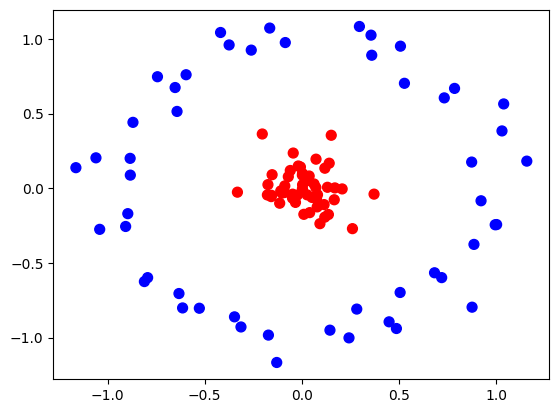

In [3]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

X, y = make_circles(
    n_samples=100,
    factor=0.1,
    noise=0.1,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.show()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [5]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [6]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

In [7]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\Msi Laptop\AppData\Local\Temp\ipykernel_17148\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


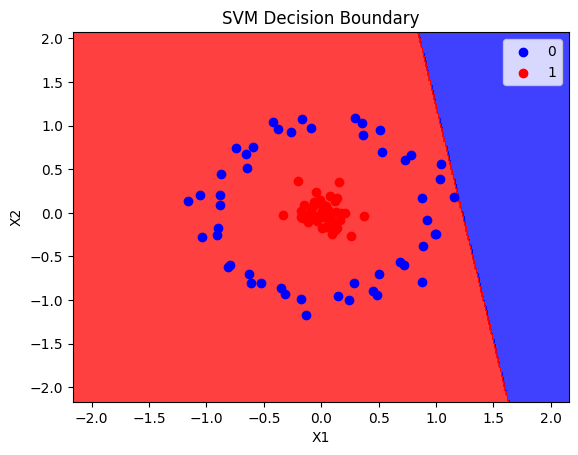

In [8]:
plot_decision_boundary(X, y, classifier)

In [9]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

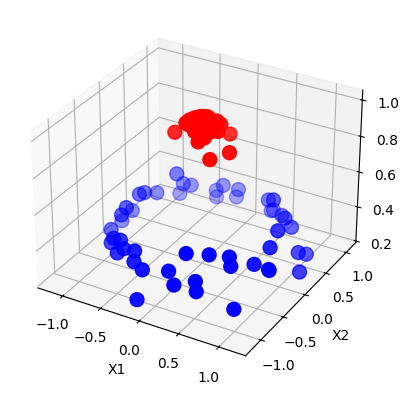

In [10]:
plot_3d_plot(X,y)

In [11]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [12]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\Msi Laptop\AppData\Local\Temp\ipykernel_17148\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


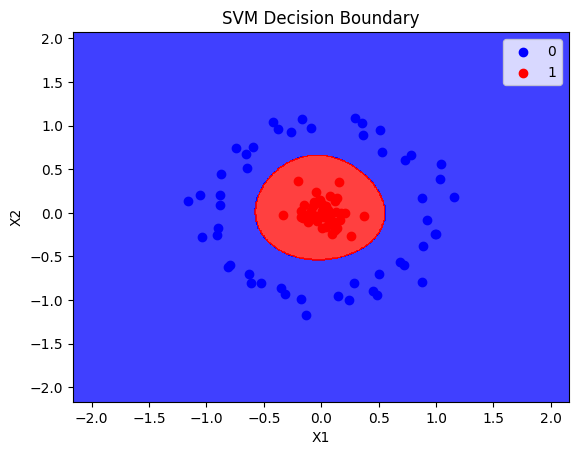

In [13]:
plot_decision_boundary(X, y, rbf_classifier)

In [14]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [15]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\Msi Laptop\AppData\Local\Temp\ipykernel_17148\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


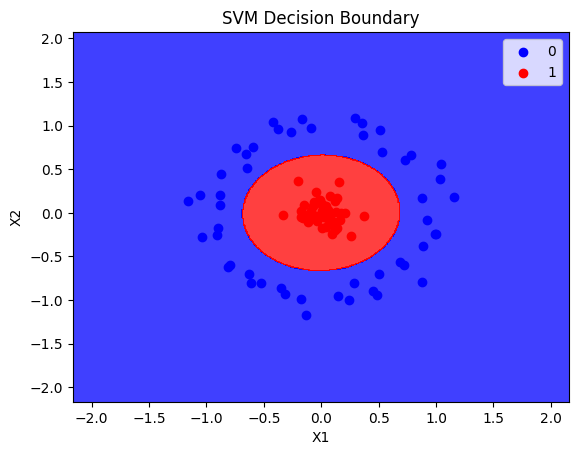

In [16]:
plot_decision_boundary(X, y, poly_classifier)

In [17]:
X

array([[ 0.01004783, -0.17510486],
       [ 0.14058191,  0.16717858],
       [-0.059743  ,  0.11848299],
       [ 0.71938348, -0.59898403],
       [ 0.87586276, -0.79693694],
       [ 0.28238185, -0.8096356 ],
       [-0.88398798,  0.19969581],
       [-0.04821718, -0.06689042],
       [ 0.35579647,  1.02466875],
       [ 0.92202981, -0.08438964],
       [-0.65247738,  0.67395748],
       [-0.79396809, -0.59912738],
       [ 0.16649451, -0.0776401 ],
       [-0.61403158, -0.80193362],
       [ 0.11817221,  0.13361695],
       [ 1.03859873,  0.56412698],
       [-0.06990555,  0.07712972],
       [-0.15789052, -0.05648558],
       [-0.08545191,  0.97514198],
       [-0.6327045 , -0.70551635],
       [ 0.00349741,  0.02280071],
       [ 0.07868738, -0.12537914],
       [-0.90712258, -0.25646566],
       [ 0.4487963 , -0.89499225],
       [-0.20389193,  0.36282105],
       [-0.41864357,  1.04254495],
       [ 0.24241093, -1.00243527],
       [ 0.11776295, -0.19402706],
       [ 0.35950546,

In [18]:
X_new=np.exp(-(X**2))

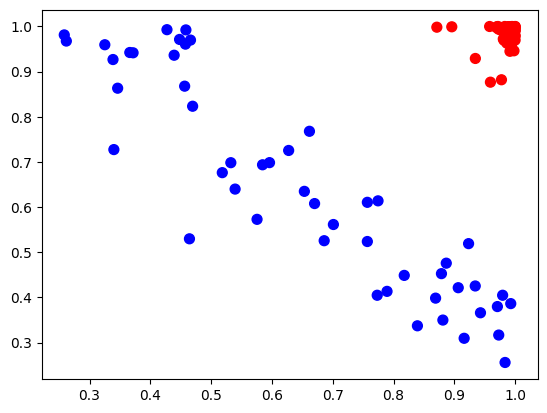

In [19]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')